In [10]:
import os
import cv2
import random
import torch
import numpy as np

from torch.utils.data import Dataset
from sklearn.preprocessing import MultiLabelBinarizer
from PIL import Image
from scipy.io import loadmat

from pathlib import Path

In [11]:
# Step 1: Load the MATLAB .mat file
current_dir = os.getcwd()
print('cerrent-dir=',current_dir)
try:
    mat_data = loadmat("./data/val_all.mat")  # Replace with your .mat file name
except FileNotFoundError:
    print("Error: The specified .mat file was not found.")
    exit(1)

# Step 2: Extract the cell array
# Replace 'myCellArray' with the actual variable name in your .mat file
if 'Path' not in mat_data:
    print("Error: 'Path' not found in the .mat file.")
    exit(1)
if 'Label' not in mat_data:
    print("Error: 'Label' not found in the .mat file.")
    exit(1)

#print('mat_data=', mat_data)
path_array = mat_data['Path']
label_array = mat_data['Label']
print('path, label size=', path_array.size, len(label_array))
print('path12 =', path_array[0],label_array[0])

#cell_array = mat_data['imgPath']


cerrent-dir= /mnt/e/Data/2026-RARE-Vision-Gastro/galar_dataset/notebooks
path, label size= 10890 10890
path12 = [array(['data/Galar_Frames_1_to_10/1/frame_000100.PNG'], dtype='<U44')] [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
# Step 3: Convert MATLAB cell array to a Python list
# MATLAB cell arrays load as object arrays in NumPy
train_path_list = []
train_label_list = []
#path_array = path_array

In [13]:
for row in path_array:
    train_path_list.append([elem.item() if hasattr(elem, 'item') else elem for elem in row])
for row in label_array:
    train_label_list.append([elem.item() if hasattr(elem, 'item') else elem for elem in row])
#train_path_list = np.array(path_array)
#train_label_list = np.array(label_array)
print('train_list12=', len(train_path_list),train_path_list[0], len(train_label_list),train_label_list[0])

# Step 4: Convert to NumPy array (optional, depending on your needs)
numpy_array_path = np.array(train_path_list) #, dtype=object)
numpy_array_label = np.array(train_label_list) #, dtype=object)
print('train_list12=', len(numpy_array_path),numpy_array_path[0][0], len(numpy_array_label),numpy_array_label[0])
# Step 5: Save as .npy file
np.save("val_path.npy", numpy_array_path)
np.save("val_label.npy", numpy_array_label)

print("✅ Conversion complete. Saved as train_label.npy + train_path_npy")

train_list12= 10890 ['data/Galar_Frames_1_to_10/1/frame_000100.PNG'] 10890 [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
train_list12= 10890 data/Galar_Frames_1_to_10/1/frame_000100.PNG 10890 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
✅ Conversion complete. Saved as train_label.npy + train_path_npy


In [14]:
# Save the img_path to a file
#np.save('img_data_path', paths0)
current_dir = os.getcwd()
print('cerrent-dir=',current_dir)

# Load the array from the file
paths = np.load('val_path.npy')
labels = np.load('val_label.npy');
print('sz=',len(paths), len(labels))
print('paths123=',paths[0:2])
print('Labels123=', labels[-1])

#paths = sorted(paths)

cerrent-dir= /mnt/e/Data/2026-RARE-Vision-Gastro/galar_dataset/notebooks
sz= 10890 10890
paths123= [['data/Galar_Frames_1_to_10/1/frame_000100.PNG']
 ['data/Galar_Frames_1_to_10/1/frame_000105.PNG']]
Labels123= [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


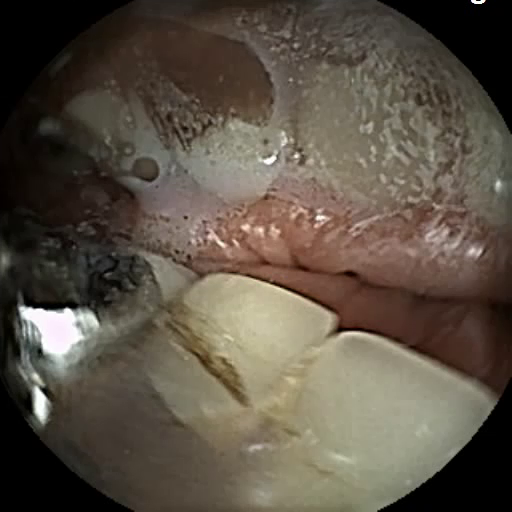

In [52]:
#Displaying an image
 # get image
image_path = paths[0][-1]
image = Image.open(image_path).convert("RGB")
display(image)
